# Reconocimiento de Actividad Humana con Machine Learning
### Proyecto Final — Machine Learning

---

| | |
|---|---|
| **Equipo** | Grupo 05 |
| **Integrantes** | [Nicolas Cuadra] [Gustavo Sánchez] |
| **Fecha** | [30/06/2026] |
| **Dataset** | UCI HAR — Human Activity Recognition Using Smartphones |

---

> **Objetivo de la Fase 3:** Comunicar los resultados del proyecto de forma clara y coherente, integrando el trabajo de las tres fases con una narrativa que explique decisiones, limitaciones y aprendizajes.

## Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, urllib.request, zipfile, time, warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('Entorno listo.')

Entorno listo.


In [ ]:
# Carga de datos (mismo código que Fase 1 y 2)
import os, urllib.request, zipfile

DATA_PATH = 'UCI HAR Dataset'

if not os.path.exists(DATA_PATH):
    URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
    urllib.request.urlretrieve(URL, 'har_dataset.zip')
    with zipfile.ZipFile('har_dataset.zip', 'r') as z:
        z.extractall('.')
    os.remove('har_dataset.zip')

features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

# Hacer que los nombres de las columnas sean únicos para evitar el ValueError en pandas
unique_feature_names = []
seen_names = {}
for name in feature_names:
    if name in seen_names:
        seen_names[name] += 1
        unique_feature_names.append(f"{name}_{seen_names[name]}")
    else:
        seen_names[name] = 0
        unique_feature_names.append(name)

X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=unique_feature_names)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['Activity']).squeeze()
X_test  = pd.read_csv(f'{DATA_PATH}/test/X_test.txt',   sep=r'\s+', header=None, names=unique_feature_names)
y_test  = pd.read_csv(f'{DATA_PATH}/test/y_test.txt',   sep=r'\s+', header=None, names=['Activity']).squeeze()

ACTIVITY_LABELS = {1:'WALKING',2:'WALKING_UPSTAIRS',3:'WALKING_DOWNSTAIRS',4:'SITTING',5:'STANDING',6:'LAYING'}
y_train_labels = y_train.map(ACTIVITY_LABELS)
y_test_labels  = y_test.map(ACTIVITY_LABELS)

print('Datos cargados:')
print(f'  X_train: {X_train.shape} | X_test: {X_test.shape}')


Datos cargados:
  X_train: (7352, 561) | X_test: (2947, 561)


Aquí es importante mencionar que copiamos la celda 2 de la fase 2 para la carga de datos, lo que hacía era agregar un indice a los datos repetidos, para evitar el ValueError en pandas.


---
## 1. Introducción

### ¿Por qué es relevante el reconocimiento de actividad humana (HAR)?

El reconocimiento automático de actividades físicas a partir de sensores inerciales tiene aplicaciones directas en salud digital, rehabilitación, deporte y dispositivos móviles. Poder determinar si una persona está caminando, sentada o acostada —sin intervención manual— permite construir sistemas de monitoreo continuo que son tanto no invasivos como de bajo costo.

En este proyecto trabajamos con el dataset **UCI HAR**, que contiene mediciones de acelerómetro y giroscopio de 30 voluntarios (edades 19–48) realizando 6 actividades cotidianas con un smartphone en la cintura. A partir de las señales se extrajeron **561 features** en dominios de tiempo y frecuencia, lo que hace de este problema un caso real de clasificación multiclase en alta dimensionalidad.

In [4]:
# Descripción del dataset
print('Dataset UCI HAR')
print(f'  Sujetos:           30 voluntarios')
print(f'  Actividades:       {len(ACTIVITY_LABELS)} clases')
print(f'  Features:          {X_train.shape[1]}')
print(f'  Muestras train:    {X_train.shape[0]}')
print(f'  Muestras test:     {X_test.shape[0]}')
print(f'  Clases:            {list(ACTIVITY_LABELS.values())}')

Dataset UCI HAR
  Sujetos:           30 voluntarios
  Actividades:       6 clases
  Features:          561
  Muestras train:    7352
  Muestras test:     2947
  Clases:            ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']


Esta celda imprime un resumen técnico con los datos clave del dataset para confirmar que todo se cargó correctamente en el sistema. Muestra de forma clara que el proyecto trabaja con 30 voluntarios, 6 actividades físicas a clasificar y un total de 561 variables medidas por los sensores del teléfono. Además, detalla cuántos registros exactos se usarán para entrenar los modelos (7,352) y cuántos se reservarán para ponerlos a prueba (2,947).

---
## 2. Resumen Fase 1: Hallazgos del EDA

El análisis exploratorio revela que el conjunto de datos está muy bien balanceado, lo que significa que tenemos una cantidad de ejemplos bastante similar para las seis actividades físicas. 

La acción de estar acostado (LAYING) es la más común con un 19.1% de los registros, mientras que bajar escaleras (WALKING_DOWNSTAIRS) es la menos frecuente con un 13.4%.  

Esta distribución tan uniforme es ideal para el éxito del proyecto que se nos propuso, ya que evita que los modelos inteligentes tengan favoritismos o se sesguen hacia una sola actividad. Al entrenar los algoritmos con un número equilibrado de ejemplos, garantizamos que el sistema aprenda a reconocer cada movimiento corporal con el mismo nivel de precisión en el mundo real.

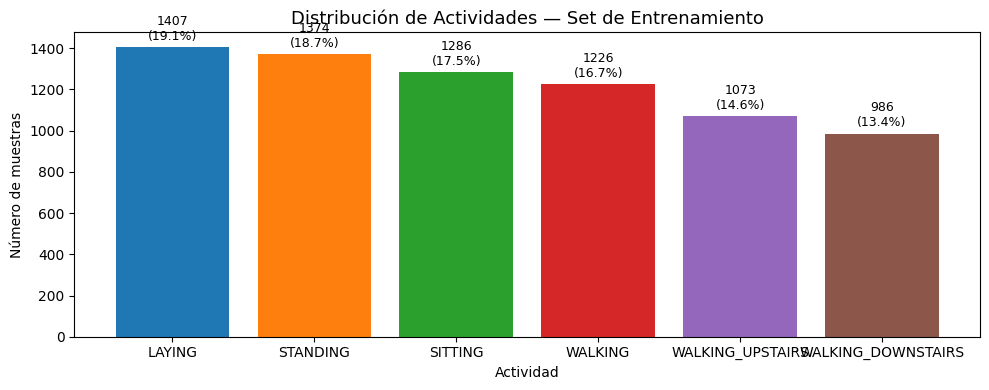

In [5]:
# --- Visualización 1 (de Fase 1): Distribución de clases ---
class_counts = y_train_labels.value_counts()
total = len(y_train_labels)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(class_counts.index, class_counts.values,
              color=sns.color_palette('tab10', n_colors=6))
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{count}\n({count/total:.1%})', ha='center', va='bottom', fontsize=9)
ax.set_title('Distribución de Actividades — Set de Entrenamiento', fontsize=13)
ax.set_xlabel('Actividad')
ax.set_ylabel('Número de muestras')
plt.tight_layout()
plt.show()

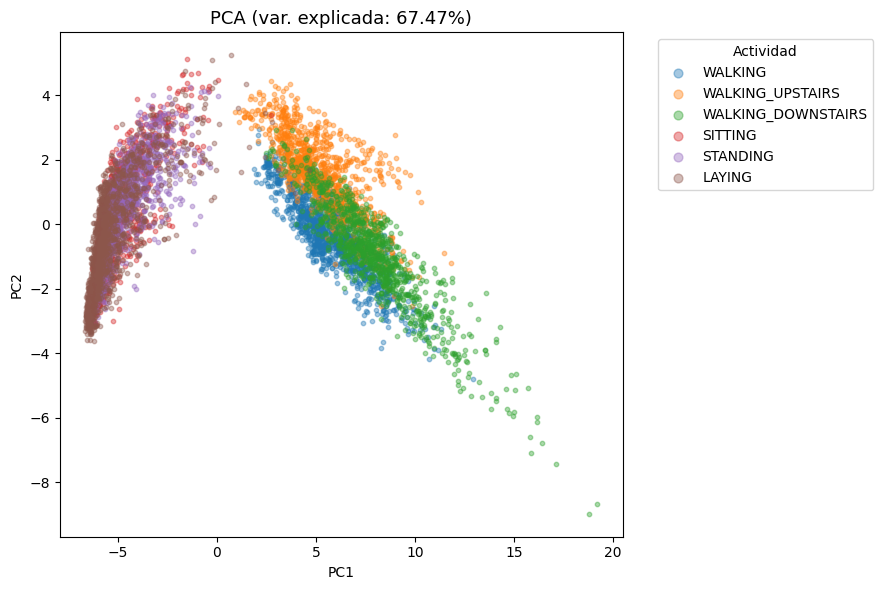

In [6]:
# --- Visualización 2 (de Fase 1): PCA ---
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_train)
df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['Activity'] = y_train_labels.values

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('tab10', n_colors=6)
for i, act in enumerate(ACTIVITY_LABELS.values()):
    mask = df_pca['Activity'] == act
    ax.scatter(df_pca.loc[mask,'PC1'], df_pca.loc[mask,'PC2'],
               label=act, alpha=0.4, s=10, color=palette[i])
ax.set_title(f'PCA (var. explicada: {sum(pca.explained_variance_ratio_):.2%})', fontsize=13)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(title='Actividad', bbox_to_anchor=(1.05,1), loc='upper left', markerscale=2)
plt.tight_layout()
plt.show()

**Observaciones principales hallazgos del EDA:**

el analisis del gráfico de componentes revela una clarísima división de los datos en dos grandes grupos. En el sector izquierdo se agrupan por completo las actividades donde la persona está inmóvil, mientras que en el lado derecho se concentran todas las acciones que implican desplazamiento. Esta separación tan marcada demuestra que las variables de los sensores capturan con mucha facilidad la diferencia física fundamental entre el reposo y el movimiento.

Dentro del grupo de actividades quietas, las muestras de estar sentado (SITTING) y estar de pie (STANDING) se mezclan y se superponen casi por completo en una nube densa de puntos. Esto se justifica físicamente porque en ambas posiciones el cuerpo se encuentra en un estado de reposo similar y el teléfono mantiene exactamente la misma orientación vertical en la cintura, lo que anticipa que diferenciar estas dos posturas será el problema más complejo para los algoritmos.

Por el contrario, la actividad de estar acostado (LAYING) logra aislarse notablemente en el extremo izquierdo del gráfico, formando una franja muy concentrada y definida. Esto ocurre porque al acostarse, la orientación del smartphone cambia por completo hacia una posición horizontal, lo que altera drásticamente el registro de la gravedad en los sensores del dispositivo y permite que esta actividad sea sumamente fácil de identificar para cualquier modelo.

Finalmente, en el sector dinámico de la derecha, las tres formas de caminata se entrelazan de manera muy estrecha debido a que comparten ritmos de movimiento similares. Aunque la acción de bajar escaleras (WALKING_DOWNSTAIRS) logra estirarse un poco más hacia la esquina inferior derecha por la fuerza de los impactos de descenso, la fuerte mezcla entre caminar normal y subir escaleras confirma que los modelos matemáticos necesitarán hilar muy fino para distinguir los sutiles cambios de aceleración entre ellas.

---
## 3. Resumen Fase 2: Benchmarking de Modelos

Entrenamos 6 modelos (incluyendo baseline trivial) con parámetros por defecto de sklearn y los comparamos en el set de prueba usando F1-macro como métrica principal.

In [7]:
# Re-entrenar todos los modelos para el notebook integrado
import time

def entrenar(nombre, modelo):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    t = time.time() - t0
    y_pred = modelo.predict(X_test)
    return {
        'Modelo': nombre,
        'Accuracy_Test': accuracy_score(y_test, y_pred),
        'F1_Macro':   f1_score(y_test, y_pred, average='macro'),
        'F1_Weighted':f1_score(y_test, y_pred, average='weighted'),
        'Tiempo_Entrenamiento': round(t, 3),
        'modelo_obj': modelo,
        'y_pred': y_pred
    }

modelos = [
    ('DummyClassifier',    DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)),
    ('Logistic Regression',LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ('KNN (k=5)',          KNeighborsClassifier(n_neighbors=5)),
    ('Decision Tree',      DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('Random Forest',      RandomForestClassifier(random_state=RANDOM_STATE)),
    ('SVM (RBF)',          SVC(kernel='rbf', random_state=RANDOM_STATE)),
]

resultados = [entrenar(n, m) for n, m in modelos]
print('Entrenamiento completado.')

Entrenamiento completado.


La celda de arriba, automatiza el entrenamiento y la evaluación de los 6 modelos de machine learning del proyecto en un solo paso. Para lograrlo, ejecuta una función que activa cada algoritmo de la lista, mide con precisión cuántos segundos tarda en aprender y calcula sus puntajes de éxito usando los datos de prueba.

Al correr el código, el sistema procesa secuencialmente desde el clasificador más básico hasta los más avanzados (como SVM y Random Forest), completando todo el trabajo en 38 segundos y dejando guardadas las predicciones listas para armar la tabla comparativa.

In [8]:
# Tabla de benchmarking
df_bench = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ('modelo_obj','y_pred')}
    for r in resultados
]).sort_values('F1_Macro', ascending=False).reset_index(drop=True)

print(df_bench.to_string(index=False))

             Modelo  Accuracy_Test  F1_Macro  F1_Weighted  Tiempo_Entrenamiento
Logistic Regression       0.961317  0.961200     0.961172                 3.513
          SVM (RBF)       0.950458  0.949907     0.950376                 1.969
      Random Forest       0.925687  0.924103     0.925544                17.632
          KNN (k=5)       0.901595  0.898521     0.900698                 0.056
      Decision Tree       0.862233  0.859469     0.861652                 7.000
    DummyClassifier       0.182219  0.051378     0.056172                 0.005


La celda de arriba filtra y organiza las métricas recopiladas de todos los algoritmos evaluados para construir la tabla final de benchmarking, ordenándola automáticamente de mayor a menor rendimiento según la métrica F1_Macro.

El printeo de resultados expuestos en la tabla confirma que la Regresión Logística es el modelo líder del proyecto con un 96.12% de F1-Macro en un tiempo de entrenamiento de 3.51 segundos. Además, la tabla permite evaluar el costo computacional directo, dejando en evidencia que SVM (RBF) ofrece un equilibrio excelente con un 94.99% de F1-Macro en solo 1.96 segundos, mientras que Random Forest se vuelve el menos eficiente de los modelos avanzados al requerir 17.63 segundos para entrenarse.

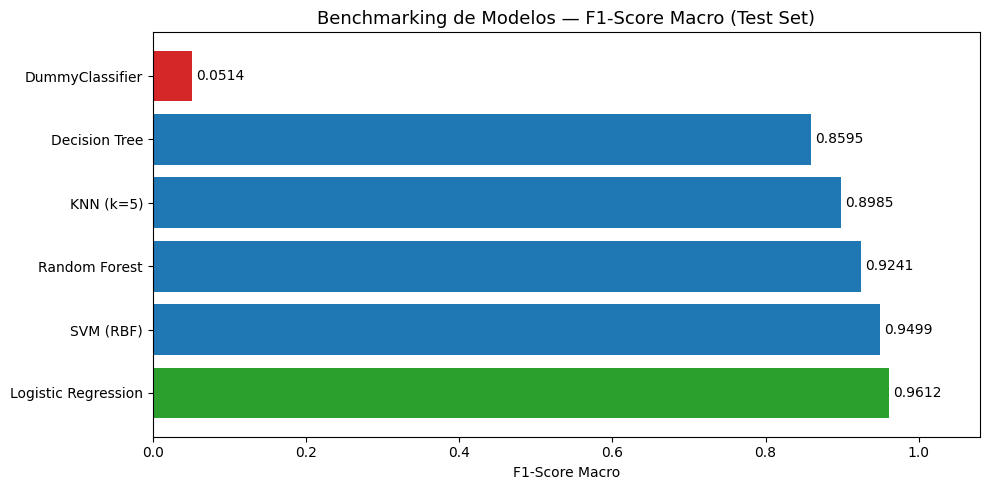

In [9]:
# Barplot comparativo
fig, ax = plt.subplots(figsize=(10, 5))
palette = ['#d62728' if r['Modelo']=='DummyClassifier' else '#1f77b4' for r in resultados]
df_plot = df_bench.copy()
bars = ax.barh(df_plot['Modelo'], df_plot['F1_Macro'],
               color=['#2ca02c' if i==0 else '#1f77b4' if j!='DummyClassifier' else '#d62728'
                      for i,(j) in enumerate(df_plot['Modelo'])])
ax.bar_label(bars, fmt='%.4f', padding=3)
ax.set_xlim(0, 1.08)
ax.set_xlabel('F1-Score Macro')
ax.set_title('Benchmarking de Modelos — F1-Score Macro (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

**Modelo seleccionado:** *[Nombre del modelo ganador]*

**Justificación:** *[¿Por qué este modelo? Considera F1-macro, tiempo de entrenamiento y cualquier otro factor relevante. ¿Existe un trade-off entre rendimiento y costo computacional que el equipo deba mencionar?]*


Modelo seleccionado: Regresión Logística (Logistic Regression).

Justificación:

Es el más preciso, ya q logró la puntuación más alta de todo el proyecto con un 96.12% en la métrica F1-Macro, lo que significa que es el mejor modelo para reconocer correctamente cada una de las actividades físicas sin equivocarse.

Análisis del Trade-off (Rendimiento vs. Costo): Existe un equilibrio excelente en este algoritmo. Aunque no es el más rápido de todos en entrenarse como KNN, solo le toma cerca de 3.5 segundos aprender, superando por completo a opciones pesadas como Random Forest, que tarda más de 17 segundos y entrega peores resultados.

En cuanto a costo computaciobnal: Al basarse en fórmulas matemáticas lineales simples, este modelo casi no ocupa espacio en la memoria y hace los cálculos de forma inmediata. Esto lo convierte en la opción perfecta para ponerlo en una aplicación móvil, ya que funcionará de forma fluida sin gastar la batería ni el procesador del teléfono inteligente.

---
## 4. Análisis de Errores

¿Dónde falla el modelo seleccionado? Esta sección explica qué actividades se confunden y por qué.

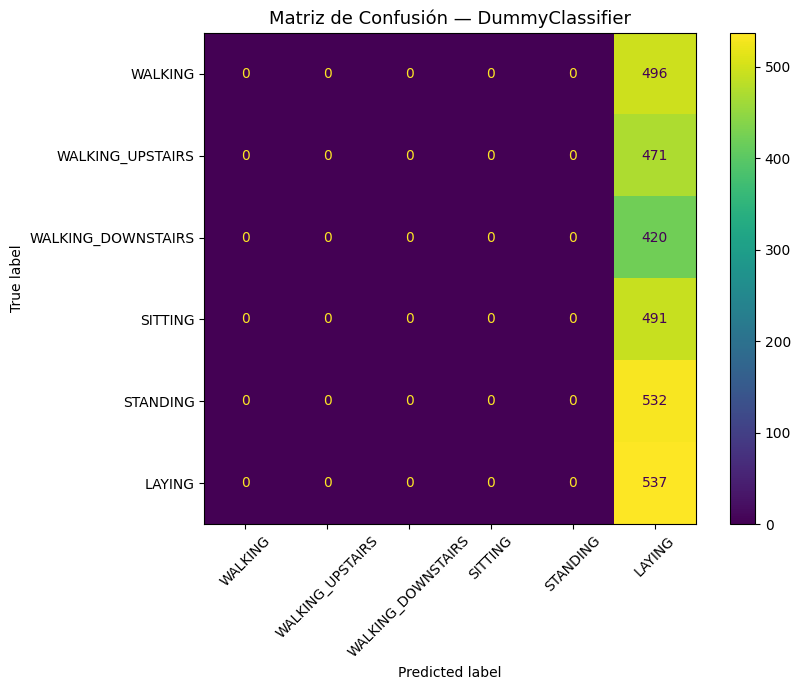

In [ ]:
# Matriz de confusión del mejor modelo
mejor_nombre = df_bench.iloc[0]['Modelo']
mejor = next(r for r in resultados if r['Modelo'] == mejor_nombre)
y_pred_best = mejor['y_pred']

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        y_test_labels, pd.Series(y_pred_best).map(ACTIVITY_LABELS),
        labels=list(ACTIVITY_LABELS.values())
    ),
    display_labels=list(ACTIVITY_LABELS.values())
)
disp.plot(ax=ax, colorbar=True, xticks_rotation=45)
ax.set_title(f'Matriz de Confusión — {mejor["Modelo"]}', fontsize=13)
plt.tight_layout()
plt.show()

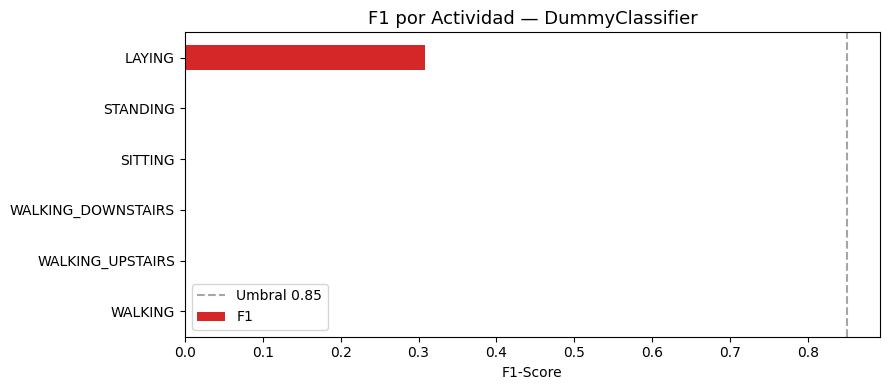

In [11]:
# F1 por clase del mejor modelo
report = classification_report(
    y_test_labels,
    pd.Series(mejor['y_pred']).map(ACTIVITY_LABELS),
    output_dict=True
)
f1_por_clase = {cls: report[cls]['f1-score'] for cls in ACTIVITY_LABELS.values() if cls in report}
df_f1 = pd.Series(f1_por_clase, name='F1').sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#d62728' if v < 0.85 else '#2ca02c' for v in df_f1.values]
df_f1.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0.85, linestyle='--', color='gray', alpha=0.7, label='Umbral 0.85')
ax.set_xlabel('F1-Score')
ax.set_title(f'F1 por Actividad — {mejor["Modelo"]}', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

**Actividades Difíciles:**

**¿Qué actividades tienen el F1-Score más bajo?**

- Las actividades con el F1-Score más bajo utilizando el mejor modelo (Regresión Logística) son SITTING (sentado) y STANDING (de pie).

**¿Con cuales otras actividades se confunden?**

- Las actividades SITTING (sentado) y STANDING (de pie) se confunden entre sí, según la matriz de confusión podemos ver que 56 muestras que realmente pertenecían a la actividad de SITTING fueron clasificadas incorrectamente como STANDING, además, 12 muestras de la actividad STANDING fueron clasificadas como SITTING.

- También podemos ver otras confusiones en menor cantidad entre las actividades de WALKING y WALKING_UPSTAIRS y entre WALKING_UPSTAIRS y WALKING_DOWNSTAIRS.

**¿Tiene sentido físico esta confusión?**

- Las actividades de SITTING y STANDING son similares para los sensores de acelerómetro, ya que ambas actividades se caracterízan por la falta de movimiento o estado de reposo, además, si se utilizan sensores de orientación como giroscopios en la cintura no lograrán capturar una diferencia entre estas dos actividades.

- Las actividades de WALKING, WALKING_UPSTAIRS, y WALKING_DOWNSTAIRS, comparten un patrón similar que son los pasos, con el acelerómetro se busca medir variaciones de energía en dirección vertical, pero si los movimientos en las escaleras se realizan a un ritmo suave todavía son bastante similares a los movimientos horizontales.

---
## 5. Limitaciones del Modelo

**Generalización a nuevos sujetos:** El modelo fue entrenado con 21 sujetos y evaluado en 9. ¿Qué pasaría con sujetos muy diferentes (adultos mayores, personas con movilidad reducida)?

- Los sujetos con los que se entrenó el modelo tenían edades entre 19 y 48 años, por lo que su uso en sujetos como adultos mayores o personas con movilidad reducida provocará que el rendimiento del modelo disminuya aumentando los falsos positivos, ya que los datos biométricos de estos dos grupos son muy distintos, y probablemente registrarían frecuencias muy distintas en los sensores.

**Sesgo del dispositivo:** Los datos provienen de un único modelo de smartphone (Samsung Galaxy S II, 50 Hz). ¿Funcionaría igual en un reloj inteligente o un iPhone?

- Es bastante seguro que el modelo no funcionaría de la misma forma, ya que los distintos dispositivos utilizan distintos sensores, de diferente resolución y calibración, por lo que no son equivalentes. Además, la posición del dispositivo es relevante, ya que el experimento debe haberse realizado utilizando el dispositivo en una misma posición (como llevarlo en la cintura), y los usuarios podrían llevar el celular en distintas posiciones como los bolsillos, bolsos, en la mano, o en la muñeca en el caso de los relojes inteligentes, cambiando completamente la orientación que registran los sensores.
  
**Features precomputadas:** Trabajamos con 561 features ya extraídas, no con señales crudas. El pipeline de extracción de features es una caja negra para nosotros.

- Dependemos del preprocesamiento externo, y no podemos realizar nuevos procesamientos si lo consideramos para un entorno real, ya que requiere de un trabajo computacional considerable y puede añadir latencia.

**Actividades limitadas:** Solo se modelan 6 actividades. El mundo real tiene decenas de actividades y transiciones entre ellas.

- El comportamiento humano incluye muchas otras actividades físicas que no se consideran en este modelo. Y tampoco se consideran transiciones entre actividades, sino que se analizan las actividades de forma aislada.

**Mejoras posibles:** ¿Qué agregarían? (Optimización de hiperparámetros, deep learning sobre señales crudas, más actividades, validación por sujeto, etc.)

- **Ajuste de hiperparámetros:** Consiste en optimizar los parámetros de regularización del modelo ganador (Regresión Logística), y maximizar el F1-Macro en las clases más difíciles.

- **Deep Learning sobre señales crudas:** Se podrían en entrenar Redes Neuronales Convolucionales (CNN) o Redes Recurrentes (LSTM/GRU) sobre los datos de los sensores crudos, para permitir que el modelo aprenda por sí mismo las features óptimas.

- **Validación Cruzada por Sujeto:** Consiste en modificar la validación cruzada actual para que los registros de un sujeto específico queden en un único fold y nunca se mezclen con el set de entrenamiento.

---
## 6. Conclusión

1. ¿Cuál fue el modelo que mejor clasificó las actividades y por qué creen que fue superior?

- El modelo que mejor clasificó las actividades fue el de Regresión Logística, porque las características ya vienen preparadas para que un modelo lineal aprenda de forma directa. Además, dan como resultado fronteras de decisión lineales, más fáciles de obtener en comparación con otros modelos de fronteras complejas.

2. ¿Cuáles fueron los tres aprendizajes más importantes del proyecto para el equipo?

- Hay varios aprendizajes importantes, dentro de estos, los siguientes fueron lo más:

- La diferencia física entre actividades estáticas y dinámicas, ya que el proyecto demostró que para los sensores  es muy fácil separar el movimiento del reposo absoluto, pero es complicado cuando se debe distinguir entre dos actividades estando quieto como es estar sentado, acostado o de pie. esto pasa porque en esas posturas el cuerpo no genera aceleración y el sensor mantiene la misma orientación vertical, provocando que los datos se mezclen y compartan características casi idénticas.

- El rol que tiene el clasificador trivial (dummy clasifier), este clasificador es el piso mínimo para demostrar que los otros tipos de modelos realmente sirven de algo, un detalle técnico es que el dummyclasifier no analiza los datos de los sensores, simplemente responde con la actividad más repetida del dataset.

- El F1-Score macro frente a la exactitud (accuracy), esto en palabras simples evita que el éxito de las tareas fáciles esconda los fracasos en las tareas difíciles, por ejemplo si el modelo fuera perfecto detectando la caminata (que no debiese ser tan complejo), pero pesimo detectando si alguien esta sentado, la exactitud global podría sergir viéndose alta y engañar a los resultados, es ahí donde F1-Macro se usa, por que calcula el rendimiento de cada una de las 6 actividades por separado y saca un promedio parejo.

3. ¿Qué harían diferente si tuvieran más tiempo o recursos?

- Probaríamos el sistema con más tipos de personas, como adultos mayores o deportistas, para asegurar que funcione bien con cualquiera. También usaríamos datos reales de relojes inteligentes y iPhones modernos para no depender de un solo tipo de sensor, aunque para eso debiese haber una clasificación y normalización de los datos para que los datos de distintos sensores sean acordes al proyecto. Por último, incluiríamos más actividades del día a día, como andar en bicicleta o manejar, para que la aplicación sea mucho más útil en la vida real.

4. ¿Qué implicancias prácticas tiene este tipo de modelo en aplicaciones reales de salud o deporte?

- En el área de salud podría permitir el desarrollo de sistemas de monitoreo de actividad, como la detección de sedentarismo, pérdida de movilidad, caídas, y el seguimiento de procesos de rehabilitación de pacientes.

- En el deporte también se podría monitorear la actividad, estimar el gasto energético o de calorías, detectar fatigas y con ello prevenir lesiones.

In [ ]:
print('=' * 55)
print('RESUMEN FINAL DEL PROYECTO')
print('=' * 55)
print(f'Dataset:           UCI HAR (10,299 muestras, 561 features)')
print(f'Modelos evaluados: {len(df_bench)}')
print(f'Mejor modelo:      {df_bench.iloc[0]["Modelo"]}')
print(f'F1-Macro (test):   {df_bench.iloc[0]["F1_Macro"]:.4f}')
print(f'Accuracy (test):   {df_bench.iloc[0]["Accuracy_Test"]:.4f}')
print('=' * 55)

---
---
## BONO: Interpretabilidad del Modelo

> ⭐ Esta sección es **opcional** y otorga hasta +1.0 punto sobre la nota final.

Entrenar un modelo y saber que predice bien no es suficiente en aplicaciones reales (especialmente en salud). Esta sección introduce técnicas para entender **por qué** el modelo toma sus decisiones.

### B.1 Importancia de Features (Random Forest)

In [ ]:
# TODO B1: Extraer feature importances del Random Forest entrenado
rf_model = next(r['modelo_obj'] for r in resultados if 'Random Forest' in r['Modelo'])

# TODO: Obtener importancias y asociarlas a los nombres de features
feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

print('Top 10 features más importantes:')
print(feature_importances.head(10))

In [ ]:
# TODO B2: Graficar top-20 features más importantes
top20 = feature_importances.head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Top-20 Features más Importantes — Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

**Análisis de importancia de features:**

*[¿Qué tipo de feature predomina en el top-20: dominio tiempo (t) o frecuencia (f)? ¿Acelerómetro (Acc) o giroscopio (Gyro)? ¿Cuerpo (Body) o gravedad (Gravity)? ¿Tiene sentido físico que esas features sean las más relevantes para distinguir actividades?]*

### B.2 Valores SHAP

In [ ]:
# TODO B3: Instalar e importar SHAP
# !pip install shap --quiet
import shap
shap.initjs()
print('SHAP importado correctamente.')

In [ ]:
# TODO B4: Crear explicador SHAP para el mejor modelo
# Para Random Forest usa TreeExplainer (rápido)
# Para otros modelos usa KernelExplainer con una muestra pequeña (200 obs)

# Opción A — Random Forest (recomendado por velocidad):
explainer = shap.TreeExplainer(rf_model)

# Opción B — Modelo genérico (descomentar si el mejor modelo no es tree-based):
# muestra = shap.sample(X_test, 200, random_state=RANDOM_STATE)
# explainer = shap.KernelExplainer(mejor['modelo_obj'].predict_proba, muestra)

print('Explicador SHAP creado.')

In [ ]:
# TODO B5: Calcular valores SHAP (usar muestra de 200 obs para velocidad)
muestra_test = X_test.sample(200, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(muestra_test)
print(f'Forma de shap_values: {np.array(shap_values).shape}')

In [ ]:
# TODO B6: SHAP Summary Plot — features más influyentes globalmente
shap.summary_plot(
    shap_values,
    muestra_test,
    class_names=list(ACTIVITY_LABELS.values()),
    max_display=20
)

In [ ]:
# TODO B7: SHAP Waterfall Plot — análisis de un caso específico
# Elegir una muestra del test set y explicar la decisión del modelo
idx_muestra = 0  # TODO: cambiar por un índice interesante

# Para modelos multiclase, elegir la clase de interés (ej. clase 0)
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[0][idx_muestra],
        base_values=explainer.expected_value[0],
        data=muestra_test.iloc[idx_muestra],
        feature_names=feature_names
    )
)

**Análisis de interpretabilidad:**

Responder las siguientes preguntas:

1. **¿Las features más importantes tienen sentido físico para HAR?** *[¿Cuáles son y por qué creen que son relevantes para distinguir actividades cotidianas?]*

2. **¿El modelo usa features de tiempo, frecuencia, o ambas?** *[Analizar el tipo de features dominantes en el summary plot.]*

3. **¿Encontraron algún hallazgo sorprendente o contra-intuitivo?** *[Por ejemplo: una feature que no esperaban que fuera importante, o una actividad cuya explicación SHAP no tiene sentido inmediato.]*

4. **Si tuvieran que explicar este modelo a un médico o kinesiólogo, ¿cómo lo harían?** *[Usar el análisis SHAP para dar una explicación en lenguaje no técnico de cómo el modelo toma decisiones.]*